In [1]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_trainer
from ncpu.config import TINY_AND_GATE_TRAINING_CONFIG

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

In [44]:
config = TINY_AND_GATE_TRAINING_CONFIG
trainer = setup_trainer(config)

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([16, 32, 32]) -> torch.Size([16, 32, 32])
  first_state: torch.Size([16, 16, 32, 32])
  rollout: torch.Size([16, 11, 16, 32, 32])
  loss: 0.0018600973999127746
Sanity check completed successfully


In [45]:
# state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
# trainer.nca.load_state_dict(state_dict)

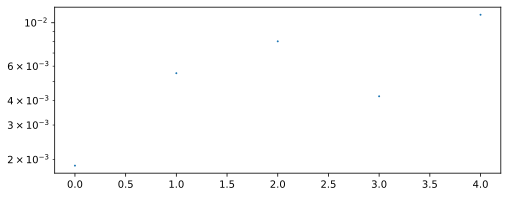

inp    : (16, 32, 32) torch.float32, min=0.00, max=1.04, mean=0.10, std=0.29
out    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.11, std=0.31
nca_out: (16, 32, 32) torch.float32, min=0.00, max=1.04, mean=0.10, std=0.29


,,,,,,,
,,,,,,,
,,,,,,,

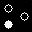
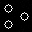
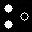
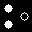
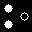
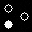
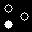
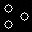
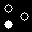
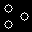
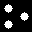
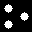
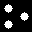
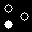
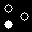
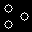
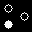
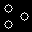
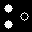
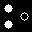
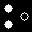
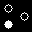
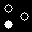
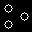

#0,#1,#2,#3,#4,#5,#6,#7

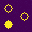
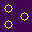
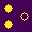
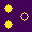
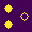
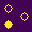
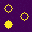
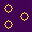

In [49]:
with torch.no_grad():
    info = trainer.optim_step(steps=(30, 80))
    trainer.display_optim_step(info)

loss=0.002983:  10%|9         | 29250/300000 [20:00<2:47:55, 26.87it/s]

inp    : (16, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.09, std=0.28
out    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.10, std=0.29
nca_out: (16, 32, 32) torch.float32, min=-0.02, max=1.01, mean=0.12, std=0.30


,,,,,,,
,,,,,,,
,,,,,,,

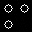
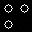
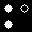
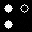
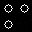
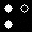
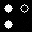
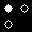
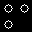
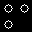
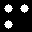
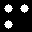
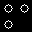
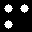
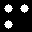
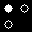
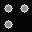
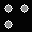
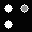
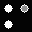
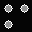
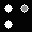
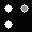
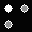

RuntimeError: Error writing '/tmp/tmpdu46e25a/file.gif': Error writing trailer of /tmp/tmpdu46e25a/file.gif: Invalid argument


In [9]:
pbar = tqdm(range(300_000))

for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 500 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()